In [1]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from blinkscolors import Colors


In [2]:
def generate_webgazer_dataframe(df):
    df_webgazer = df[~df["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        data_list = json.loads(df_webgazer["webgazer_data"].iloc[row])
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [3]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data").glob("*.csv")
dfs = []
i = 0
for file in files:
    if "blink-experiment" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        i+=1
        dfs.append(df_tmp)

df_webgazer = pd.concat(dfs)
print(len(df_webgazer))

data/blink-experiment-9.csv
2296
data/blink-experiment-15.csv
1986
data/blink-experiment-8.csv
1589
data/blink-experiment-12.csv
1900
data/blink-experiment-13.csv
1383
data/blink-experiment-11.csv
1407
data/blink-experiment-10.csv
1135
data/blink-experiment-6.csv
1432
data/blink-experiment-expose-points_1 (1).csv
1426
data/blink-experiment-7.csv
1923
data/blink-experiment-5.csv
1272
data/blink-experiment-expose-points_3.csv
2132
data/blink-experiment-expose-points_2.csv
1301
data/blink-experiment-expose-points_4.csv
1519
22701


In [4]:
blinkColors = Colors()

df_webgazer["isBlinkColors"] = df_webgazer.apply(
    lambda row: blinkColors.isBlinkByColors(
        list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
    ),
    axis=1,
)
df_webgazer

,x,y,t,importantKeypoints,leftEye,rightEye,dz,trial,experiment,file_name,isBlinkColors
0,0,0,62,"{'noseX': 288.29, 'noseY': 313.05, 'topY': 190...","{'data': {'0': 84, '1': 62, '2': 42, '3': 255,...","{'data': {'0': 144, '1': 105, '2': 82, '3': 25...",51.57,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal..."
1,0,0,81,"{'noseX': 289.14, 'noseY': 313.56, 'topY': 190...","{'data': {'0': 44, '1': 30, '2': 15, '3': 255,...","{'data': {'0': 66, '1': 41, '2': 27, '3': 255,...",52.57,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal..."
2,0,0,106,"{'noseX': 289.29, 'noseY': 313.86, 'topY': 190...","{'data': {'0': 46, '1': 31, '2': 15, '3': 255,...","{'data': {'0': 66, '1': 43, '2': 26, '3': 255,...",53.01,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal..."
3,0,0,142,"{'noseX': 288.98, 'noseY': 313.11, 'topY': 190...","{'data': {'0': 46, '1': 31, '2': 15, '3': 255,...","{'data': {'0': 64, '1': 42, '2': 25, '3': 255,...",50.86,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal..."
4,0,0,175,"{'noseX': 289.17, 'noseY': 313.61, 'topY': 190...","{'data': {'0': 48, '1': 32, '2': 16, '3': 255,...","{'data': {'0': 67, '1': 42, '2': 27, '3': 255,...",52.18,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...,...,...,...,...
490,0,0,16670,"{'noseX': 332.29, 'noseY': 308.27, 'topY': 164...","{'data': {'0': 124, '1': 97, '2': 52, '3': 255...","{'data': {'0': 116, '1': 73, '2': 27, '3': 255...",41.95,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal..."
491,0,0,16701,"{'noseX': 331.28, 'noseY': 308.62, 'topY': 165...","{'data': {'0': 128, '1': 100, '2': 58, '3': 25...","{'data': {'0': 121, '1': 77, '2': 32, '3': 255...",39.36,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal..."
492,0,0,16732,"{'noseX': 331.85, 'noseY': 308.55, 'topY': 165...","{'data': {'0': 83, '1': 58, '2': 14, '3': 255,...","{'data': {'0': 112, '1': 69, '2': 26, '3': 255...",40.61,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal..."
493,0,0,16772,"{'noseX': 331.27, 'noseY': 309.03, 'topY': 165...","{'data': {'0': 127, '1': 101, '2': 54, '3': 25...","{'data': {'0': 112, '1': 69, '2': 26, '3': 255...",39.11,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal..."


In [5]:
df_webgazer["Blink_sample"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[1]==True))
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[2]==True))
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[4]==True))
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[5]==True))
df_webgazer["Blink_sample6"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[6]==True))
df_webgazer["Blink_sample7"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[7]==True))
df_webgazer["Blink_sample8"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[8]==True))
df_webgazer["Blink_sample9"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[9]==True))

In [7]:
df_webgazer["Blink_sample0_diff"] = (df_webgazer['Blink_sample'].shift(1)+1 == df_webgazer['Blink_sample'])
df_webgazer["Blink_sample1_diff"] = (df_webgazer['Blink_sample1'].shift(1)+1 == df_webgazer['Blink_sample1'])
df_webgazer["Blink_sample2_diff"] = (df_webgazer['Blink_sample2'].shift(1)+1 == df_webgazer['Blink_sample2'])
df_webgazer["Blink_sample3_diff"] = (df_webgazer['Blink_sample3'].shift(1)+1 == df_webgazer['Blink_sample3'])
df_webgazer["Blink_sample4_diff"] = (df_webgazer['Blink_sample4'].shift(1)+1 == df_webgazer['Blink_sample4'])
df_webgazer["Blink_sample5_diff"] = (df_webgazer['Blink_sample5'].shift(1)+1 == df_webgazer['Blink_sample5'])
df_webgazer["Blink_sample6_diff"] = (df_webgazer['Blink_sample6'].shift(1)+1 == df_webgazer['Blink_sample6'])
df_webgazer["Blink_sample7_diff"] = (df_webgazer['Blink_sample7'].shift(1)+1 == df_webgazer['Blink_sample7'])
df_webgazer["Blink_sample8_diff"] = (df_webgazer['Blink_sample8'].shift(1)+1 == df_webgazer['Blink_sample8'])
df_webgazer["Blink_sample9_diff"] = (df_webgazer['Blink_sample9'].shift(1)+1 == df_webgazer['Blink_sample9'])

results = []
for x in range(0,10):
    tmp_result = df_webgazer.groupby(['trial', 'file_name'])['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

cleaned_results = [results[0]] + [df.drop(columns=['trial', 'file_name']) for df in results[1:]]
result = pd.concat(cleaned_results, axis=1)
result

,trial,file_name,Blink_sample0_diff,Blink_sample1_diff,Blink_sample2_diff,Blink_sample3_diff,Blink_sample4_diff,Blink_sample5_diff,Blink_sample6_diff,Blink_sample7_diff,Blink_sample8_diff,Blink_sample9_diff
0,1,data/blink-experiment-10.csv,13,20,11,13,19,18,13,11,9,14
1,1,data/blink-experiment-11.csv,19,19,15,21,16,19,18,13,7,17
2,1,data/blink-experiment-12.csv,5,33,1,2,33,5,1,1,1,2
3,1,data/blink-experiment-13.csv,12,26,22,20,25,18,19,19,12,18
4,1,data/blink-experiment-15.csv,22,29,15,15,24,24,16,11,6,19
...,...,...,...,...,...,...,...,...,...,...,...,...
71,6,data/blink-experiment-5.csv,27,32,21,21,27,25,21,15,8,26
72,6,data/blink-experiment-6.csv,22,34,20,21,35,24,19,18,10,27
73,6,data/blink-experiment-7.csv,26,33,27,26,31,26,27,24,16,26
74,6,data/blink-experiment-8.csv,26,40,22,23,38,27,25,23,21,24


In [8]:
threshold_columns = [col for col in result.columns if col not in ['trial', 'file_name']]
result['should_be'] = result['trial'].apply(lambda x: 2 if x == 3 else 10)
result[result['trial']==3]

,trial,file_name,Blink_sample0_diff,Blink_sample1_diff,Blink_sample2_diff,Blink_sample3_diff,Blink_sample4_diff,Blink_sample5_diff,Blink_sample6_diff,Blink_sample7_diff,Blink_sample8_diff,Blink_sample9_diff,should_be
28,3,data/blink-experiment-10.csv,7,6,7,6,6,7,6,6,6,7,2
29,3,data/blink-experiment-11.csv,8,11,7,8,10,9,7,7,3,8,2
30,3,data/blink-experiment-12.csv,3,11,1,1,10,3,1,1,1,1,2
31,3,data/blink-experiment-13.csv,5,7,6,5,10,6,7,5,3,6,2
32,3,data/blink-experiment-15.csv,9,14,6,5,15,9,6,4,2,7,2
33,3,data/blink-experiment-5.csv,2,3,2,2,3,2,2,1,1,2,2
34,3,data/blink-experiment-6.csv,6,6,5,5,6,6,5,3,3,6,2
35,3,data/blink-experiment-7.csv,7,10,4,4,10,5,5,2,2,5,2
36,3,data/blink-experiment-8.csv,8,8,5,4,7,5,5,5,4,6,2
37,3,data/blink-experiment-9.csv,5,8,6,5,6,5,7,6,5,5,2


In [9]:
threshold_columns = result.columns[2:-1]
threshold_columns

Index(['Blink_sample0_diff', 'Blink_sample1_diff', 'Blink_sample2_diff',
       'Blink_sample3_diff', 'Blink_sample4_diff', 'Blink_sample5_diff',
       'Blink_sample6_diff', 'Blink_sample7_diff', 'Blink_sample8_diff',
       'Blink_sample9_diff'],
      dtype='object')

In [10]:
metodo = "COLORS"

# Obtener las columnas de thresholds (excluyendo 'trial' y 'Should be')
threshold_columns = result.columns[2:-1]

threshold_values = ["0,78-0,85", "0,8-0,9",	"0,7-0,8", "0,6-0,8", "0,7-0,9", "0,65-0,85", "0,71-0,81", "0,71-0,79", "0,73-0,77", "0,68-0,82"]
results_global = []
for i, threshold in enumerate(threshold_columns):
    preds = result[threshold]
    truth = result['should_be']
    mae = np.mean(np.abs(preds - truth))
    rmse = np.sqrt(np.mean((preds - truth) ** 2))
    results_global.append({'Threshold': threshold_values[i], 'Error Absoluto Medio': mae, 'Error Cuadrático Medio': rmse})

results_global_df = pd.DataFrame(results_global).sort_values(by='Error Cuadrático Medio')

results_global_df.head()

results_global_df = pd.DataFrame(results_global).sort_values(by='Error Absoluto Medio')

results_global_df.head()


,Threshold,Error Absoluto Medio,Error Cuadrático Medio
8,"0,73-0,77",5.526316,7.651969
7,"0,71-0,79",8.605263,11.738376
3,"0,6-0,8",10.026316,13.589857
2,"0,7-0,8",10.197368,13.282854
6,"0,71-0,81",10.934211,14.031450


<Figure size 1400x700 with 0 Axes>

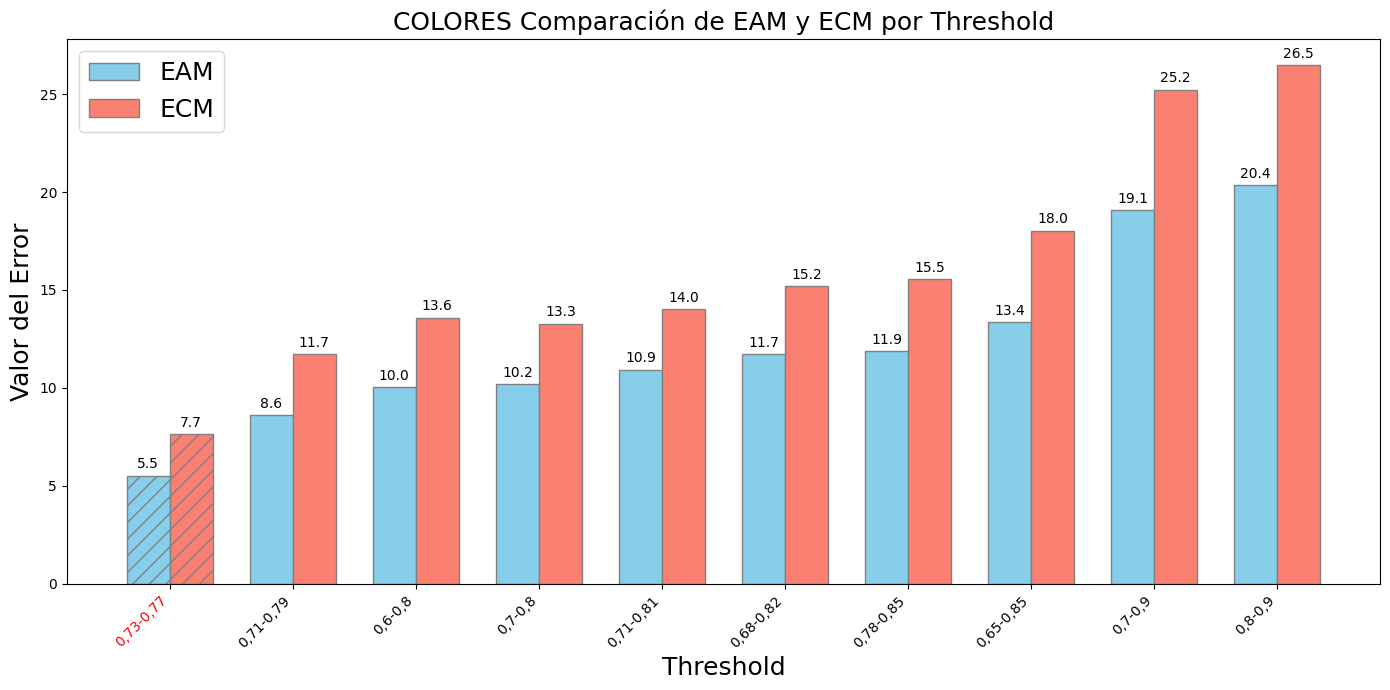


Resultados detallados:
Threshold       EAM       ECM
0,73-0,77  5.526316  7.651969
0,71-0,79  8.605263 11.738376
  0,6-0,8 10.026316 13.589857
  0,7-0,8 10.197368 13.282854
0,71-0,81 10.934211 14.031450


In [20]:
metodo = "COLORES"

# Configuración de estilo
#sns.set(style="whitegrid")
plt.figure(figsize=(14, 7))

# Calcular MAE y RMSE para cada threshold
metrics = []
for i, col in enumerate(threshold_columns):
    errors = result[col] - result['should_be']
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors**2))
    metrics.append({'Threshold': threshold_values[i], 'EAM': mae, 'ECM': rmse})

# Crear DataFrame con los resultados
metrics_df = pd.DataFrame(metrics).sort_values(by='EAM')

# Gráfico combinado (MAE y RMSE)
plt.figure(figsize=(14, 7))
bar_width = 0.35
x = np.arange(len(metrics_df))

# Barras para MAE
bars_mae = plt.bar(x - bar_width/2, metrics_df['EAM'], width=bar_width, 
                   color='skyblue', label='EAM', edgecolor='grey')

# Barras para RMSE
bars_rmse = plt.bar(x + bar_width/2, metrics_df['ECM'], width=bar_width, 
                    color='salmon', label='ECM', edgecolor='grey')

# Añadir etiquetas y formato
plt.title(metodo + ' Comparación de EAM y ECM por Threshold', fontsize=18)
plt.xlabel('Threshold', fontsize=18)
plt.ylabel('Error (en cantidad de pestaneos)', fontsize=18)
plt.xticks(x, metrics_df['Threshold'], rotation=45, ha='right')
plt.legend(fontsize=18)

# Etiquetas con valores
for bar in bars_mae + bars_rmse:
    height = bar.get_height()
    plt.annotate(f'{height:.1f}',
                 (bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom',
                 xytext=(0, 3),
                 textcoords='offset points')

# Resaltar el mejor threshold (MAE más bajo)
best_idx = metrics_df['EAM'].idxmin()
plt.gca().get_xticklabels()[0].set_color('red')
bars_mae[0].set_hatch('//')  # Patrón para resaltar
bars_rmse[0].set_hatch('//')  # Patrón para resaltar


plt.tight_layout()
plt.show()

# Mostrar tabla de resultados
print("\nResultados detallados:")
print(metrics_df.head().to_string(index=False))

In [15]:

# Filtrar columnas que contienen valores de thresholds
# Calcular MAE y RMSE

# Convertir a DataFrame y ordenar
results_df = pd.DataFrame(results_global).sort_values(by='Error Absoluto Medio')

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(results_global['Threshold'], results_df['Error Absoluto Medio'], marker='o', label='MAE')
plt.plot(results_global['Threshold'], results_df['Error Cuadrático Medio'], marker='s', label='RMSE')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Threshold Range')
plt.ylabel('Error')
plt.title('Error (MAE y RMSE) vs. Threshold Range')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


TypeError: list indices must be integers or slices, not str

<Figure size 1400x600 with 0 Axes>

In [13]:
metrics_df.head()

,Threshold,EAM,ECM
6,"0,6-0,7",12.333333,16.237816
7,"0,61-0,71",12.500000,15.900734
8,"0,61-0,69",17.666667,22.181073
10,"0,58-0,72",19.500000,23.745175
5,"0,55-0,75",30.666667,35.711809
